Epoch 10 | Loss: 2.8554
Epoch 20 | Loss: 2.7023
Epoch 30 | Loss: 2.4739
Epoch 40 | Loss: 2.1291
Epoch 50 | Loss: 1.7346


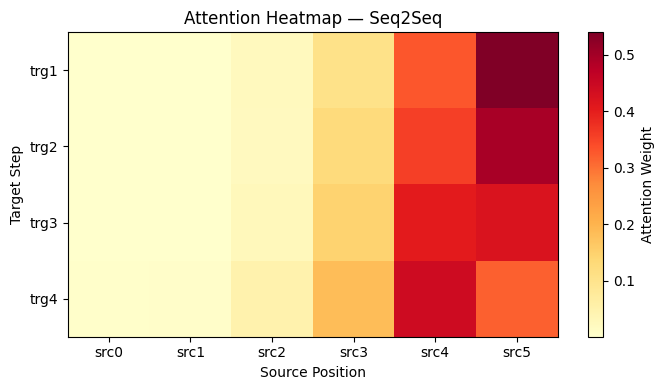

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

VOCAB, EMB, HID, SRC_LEN, TRG_LEN = 20, 16, 32, 6, 5

class AttentionEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb  = nn.Embedding(VOCAB, EMB)
        self.lstm = nn.LSTM(EMB, HID, batch_first=True)
    def forward(self, x):
        emb = self.emb(x)
        out, (h, c) = self.lstm(emb)
        return out, h, c              # out: (B, T, HID)

class AttentionDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb   = nn.Embedding(VOCAB, EMB)
        self.lstm  = nn.LSTM(EMB + HID, HID, batch_first=True)
        self.attn  = nn.Linear(HID * 2, SRC_LEN)
        self.fc    = nn.Linear(HID, VOCAB)

    def forward(self, x, h, c, enc_out):
        emb = self.emb(x.unsqueeze(1))                   # (B,1,EMB)
        # Attention
        attn_w = F.softmax(
            self.attn(torch.cat([h[-1].unsqueeze(1).expand(-1, 1, HID),
                                 h[-1].unsqueeze(1)], dim=-1)), dim=-1)  # (B,1,SRC_LEN)
        # Simpler score: dot h with each encoder step
        scores  = torch.bmm(enc_out, h[-1].unsqueeze(2)).squeeze(2)     # (B, SRC_LEN)
        attn_w  = F.softmax(scores, dim=1).unsqueeze(1)                 # (B,1,SRC_LEN)
        context = torch.bmm(attn_w, enc_out)                            # (B,1,HID)
        lstm_in = torch.cat([emb, context], dim=2)                      # (B,1,EMB+HID)
        out, (h, c) = self.lstm(lstm_in, (h, c))
        pred = self.fc(out.squeeze(1))
        return pred, h, c, attn_w.squeeze(1)             # attn_w: (B, SRC_LEN)

class AttnSeq2Seq(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = AttentionEncoder()
        self.dec = AttentionDecoder()

    def forward(self, src, trg):
        enc_out, h, c = self.enc(src)
        outputs, attentions = [], []
        x = trg[:, 0]
        for t in range(1, trg.shape[1]):
            pred, h, c, attn_w = self.dec(x, h, c, enc_out)
            outputs.append(pred.unsqueeze(1))
            attentions.append(attn_w.unsqueeze(1))
            x = trg[:, t]
        return torch.cat(outputs, dim=1), torch.cat(attentions, dim=1)

# Train
src = torch.randint(1, VOCAB, (4, SRC_LEN))
trg = torch.randint(1, VOCAB, (4, TRG_LEN))

model = AttnSeq2Seq()
opt   = torch.optim.Adam(model.parameters())
loss_fn = nn.CrossEntropyLoss()

for epoch in range(50):
    opt.zero_grad()
    out, attn = model(src, trg)
    loss = loss_fn(out.reshape(-1, VOCAB), trg[:, 1:].reshape(-1))
    loss.backward(); opt.step()
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1} | Loss: {loss.item():.4f}")

# ── Visualize Heatmap ──────────────────────────────────────────
model.eval()
with torch.no_grad():
    _, attn = model(src, trg)           # attn: (B, TRG-1, SRC_LEN)

attn_map = attn[0].numpy()             # first sample → (TRG-1, SRC_LEN)

plt.figure(figsize=(7, 4))
plt.imshow(attn_map, cmap='YlOrRd', aspect='auto')
plt.colorbar(label='Attention Weight')
plt.xlabel('Source Position')
plt.ylabel('Target Step')
plt.title('Attention Heatmap — Seq2Seq')
plt.xticks(range(SRC_LEN), [f'src{i}' for i in range(SRC_LEN)])
plt.yticks(range(TRG_LEN-1), [f'trg{i+1}' for i in range(TRG_LEN-1)])
plt.tight_layout()
plt.show()